### Imports and Setup

In [4]:
import glob

import yaml
import h5py
import numpy as np
import sklearn.model_selection

# load config file
with open("config.yaml", 'r') as yaml_file:
    config = yaml.load(yaml_file, Loader=yaml.Loader)

### Create Train/Test/Val Virtual Datasets

Define function to do train/test/val split.

In [2]:
def train_test_split_inds(*args, val_size=None, **kwargs):
    
    """
    Wrapper for sklearn.model_selection.train_test_split which also 
    does a validation split and assumes we are operating on indices
    """

    assert (val_size is None and 'test_size' in kwargs) or (val_size is not None and 'test_size' in kwargs),\
    "If you want to split into two sets, set only 'train_size' and/or 'test_size'."
    
    # if val_size is None, use base function
    if val_size is None:
        train_inds, test_inds = sklearn.model_selection.train_test_split(*args, **kwargs)
        return train_inds, np.asarray([]), test_inds 
        
    # get new test size
    test_size_1 = kwargs['test_size'] + val_size
    test_size_2 = np.around(kwargs['test_size'] / (val_size + kwargs['test_size']), 2)
    
    # first split
    kwargs['test_size'] = test_size_1
    train_inds, remain_inds = sklearn.model_selection.train_test_split(*args, **kwargs)
    
    # second split
    kwargs['test_size'] = test_size_2
    kwargs['train_size'] = None # clear whatever train setting we had for the first split
    val_inds, test_inds = sklearn.model_selection.train_test_split(remain_inds, **kwargs)
    
    return train_inds, val_inds, test_inds

Create virtual datasets.

In [14]:
# get .h5 files in data directory
files = glob.glob(config['dataset']['data_directory'] + '/*.h5')

# we assume we have these entries
assert(all(x in config['dataset']['entry_keys'] for x in ['data', 'T', 'fs']))

# create virtual sources for each entry key
sources_dict = {k : [] for k in config['dataset']['entry_keys']}
sh_dict = {}
dtype_dict = {}
total_length = 0
for i, filename in enumerate(files, start=1):
    with h5py.File(filename, 'r') as f:
        for k in config['dataset']['entry_keys']:
            
            # save entry data shapes
            if i == 1:
                sh_dict[k] = f[k].shape[1:]
                dtype_dict[k] = f[k].dtype
            
            # only add one source for 'T' and 'fs' because they're assumed
            # to all be the same
            if (k == 'T' or k == 'fs') and i > 1:
                continue
            else:
                vsource = h5py.VirtualSource(f[k])
                sources_dict[k].append(vsource)
        
        # add to total length
        total_length += f['data'].shape[0]

# make layouts
layout_dict = {}
for k in config['dataset']['entry_keys']:
    if k != 'T' and k!= 'T':
        layout_dict[k] = h5py.VirtualLayout(shape=(total_length,)+sh_dict[k], dtype=dtype_dict[k])
    else:
        layout_dict[k] = h5py.VirtualLayout(shape=(1,)+sh_dict[k], dtype=dtype_dict[k])

# fill layouts
for k in config['dataset']['entry_keys']:
    offset = 0
    for vsource in sources_dict[k]:
        length = vsource.shape[0]
        layout_dict[k][offset:offset+length] = vsource
        offset += length
        
# create virtual datasets
with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'w', libver='latest') as f:
    for k in config['dataset']['entry_keys']:
        f.create_virtual_dataset(k, layout_dict[k], fillvalue=0)

Create split indices and save them for future use.

In [15]:
# define split
splits = {'train' : 0.8, 'val' : 0.1, 'test' : 0.1}

# split
inds = train_test_split_inds(np.arange(total_length), train_size = splits['train'], test_size=splits['test'], val_size=splits['val'])

# save indices
for i, key in enumerate(splits.keys()):
    if np.any(inds[i]):
        np.save(config['dataset']['data_directory'] + f'/{key}_indices.npy', inds[i], allow_pickle=True)
        print(f'{key} size: {len(inds[i])}')

train size: 256
val size: 32
test size: 32


### Visualize Data

Labels
-------------------
Y:	-0.56 km
X:	-4.82 km
cb:	2000.0 m/s
cw:	1466.8 m/s
zs:	9.0 m
class:	1
SNRs:	[-0.64  0.45  7.85]


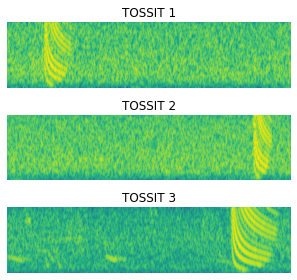

In [6]:
from utils.transformations import to_spect
from matplotlib import pyplot as plt
%matplotlib inline

# call selection
call = 10

with h5py.File(config['dataset']['data_directory'] + "/VDS_main.h5", 'r') as f:
    signals = f['data'][call,:,:]
    num_TOSSITs = f['data'].shape[1]
    y_loc = f['labels'][call,0]
    x_loc = f['labels'][call,1]
    cb = f['labels'][call,2]
    cw = f['labels'][call,3]
    zs = f['labels'][call,4]
    c = f['class_labels'][call].squeeze()
    snrs = f['labels'][call,5:]

for t in range(num_TOSSITs):
    spect = to_spect(signals[t])
    plt.subplot(num_TOSSITs,1,t+1)
    plt.imshow(spect.squeeze())
    plt.title(f"TOSSIT {t+1}")
    plt.axis('off')
plt.tight_layout()

print("Labels")
print("-------------------")
print("Y:\t" + str(np.around(y_loc,2)) + " km")
print("X:\t" + str(np.around(x_loc,2)) + " km")
print("cb:\t" + str(cb) + " m/s")
print("cw:\t" + str(cw) + " m/s")
print("zs:\t" + str(zs) + " m")
print("class:\t" + str(c))
print("SNRs:\t" + str(np.around(snrs,2)))